In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

In [ ]:
x = torch.linspace(0,1,12,dtype=torch.float32)
noise = np.random.normal(0,0.05,x.shape).astype(np.float32)
x+=noise
y=x*x

x=x.reshape(-1,1)
y=y.reshape(-1,1)

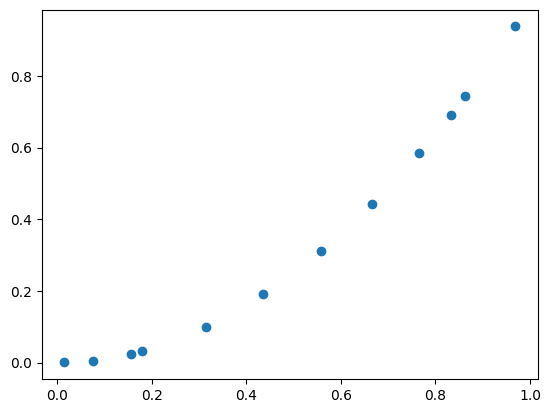

In [ ]:
plt.scatter(x,y)
plt.show()

In [ ]:
class Net(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = torch.nn.Linear(1,1)
        self.af = torch.nn.Sigmoid()
    def forward(self,x):
        return self.af(self.fc(x))

In [ ]:
model = Net()

In [ ]:
y_hat = model(x)

In [ ]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)

In [ ]:
def train(model, optimizer, criterion, x_train, y_train, epochs=160, print_every=1):
  """
  Trains a model on a given dataset.

  Args:
    model: The model to train.
    optimizer: The optimizer to use.
    criterion: The loss function to use.
    x_train: The training data.
    y_train: The training labels.
    x_test: The test data.
    y_test: The test labels.
    epochs: The number of epochs to train for.
    print_every: The frequency with which to print training loss.

  Returns:
    The trained model.
  """

  for epoch in range(epochs):
    # Clear gradient buffers because we don't want any gradient from the previous epoch to carry forward, don't want to cumulate gradients
    optimizer.zero_grad()

    # get output from the model, given the inputs
    y_hat = model(x_train)

    # get loss for the predicted output
    loss = criterion(y_hat, y_train)
    # get gradients w.r.t to parameters
    loss.backward()

    # update parameters
    optimizer.step()

    if epoch % print_every == 0:
      print(f'epoch:\t{epoch},\t loss:\t{loss.item():.2f}')

  return model

In [ ]:
model = train(model,optimizer,criterion,x,y,print_every=10)

epoch:	0,	 loss:	0.01
epoch:	10,	 loss:	0.01
epoch:	20,	 loss:	0.01
epoch:	30,	 loss:	0.01
epoch:	40,	 loss:	0.01
epoch:	50,	 loss:	0.01
epoch:	60,	 loss:	0.01
epoch:	70,	 loss:	0.01
epoch:	80,	 loss:	0.01
epoch:	90,	 loss:	0.01
epoch:	100,	 loss:	0.01
epoch:	110,	 loss:	0.01
epoch:	120,	 loss:	0.01
epoch:	130,	 loss:	0.01
epoch:	140,	 loss:	0.01
epoch:	150,	 loss:	0.01


In [ ]:
epochs = 1500
for epoch in range(epochs):
    optimizer.zero_grad()
    y_hat = model(x)
    loss = criterion(y,y_hat)
    loss.backward()
    optimizer.step()
    if epoch%10==0:
        print(f'loss:\t{loss.item()}')

loss:	0.018595615401864052
loss:	0.018127525225281715
loss:	0.017679275944828987
loss:	0.017249837517738342
loss:	0.016838209703564644
loss:	0.01644350215792656
loss:	0.016064831987023354
loss:	0.0157014150172472
loss:	0.015352476388216019
loss:	0.015017320401966572
loss:	0.014695278368890285
loss:	0.014385723508894444
loss:	0.014088060706853867
loss:	0.01380173396319151
loss:	0.013526213355362415
loss:	0.013261023908853531
loss:	0.01300568412989378
loss:	0.012759752571582794
loss:	0.012522812001407146
loss:	0.012294472195208073
loss:	0.012074354104697704
loss:	0.011862116865813732
loss:	0.0116574140265584
loss:	0.011459923349320889
loss:	0.011269353330135345
loss:	0.011085405945777893
loss:	0.010907825082540512
loss:	0.010736338794231415
loss:	0.010570707730948925
loss:	0.010410689748823643
loss:	0.010256071574985981
loss:	0.010106641799211502
loss:	0.009962190873920918
loss:	0.009822522290050983
loss:	0.009687465615570545
loss:	0.009556842036545277
loss:	0.0094304783269763
loss:	0.00

In [ ]:
pred = model(x)

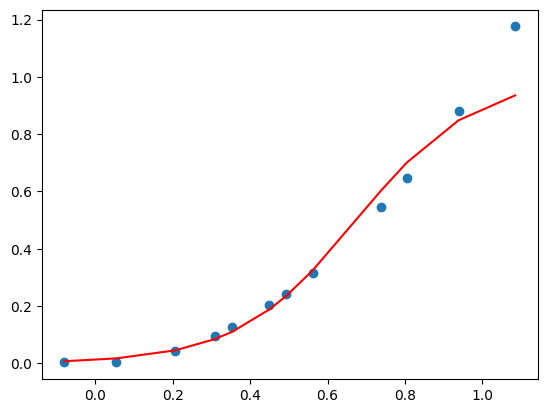

In [ ]:
plt.scatter(x,y)
plt.plot(x,pred.detach().numpy(),c='red')
plt.show()